In [ ]:
%load_ext autoreload
%autoreload 2

import sys; sys.path += ['./../']
import numpy as np
from CardamomOT import train_classifier, predict_cell_types, plot_cell_type_proportions
import anndata as ad
import getopt
import scipy
import scanpy as sc
import matplotlib.pyplot as plt

label="cell_type"
stim = 1.0
prior = 1.0

def check_cell_types_full(clf, p, test=False):

    ### Compare cell type on mRNA
    adata_train_true = ad.read_h5ad(p+'Data/data_train.h5ad')
    adata_train = ad.read_h5ad(p+'cardamom/adata_beta_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_sim_train = ad.read_h5ad(p+'cardamom/adata_sim_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_theta_train = ad.read_h5ad(p+'cardamom/adata_theta_stim{}_prior{}.h5ad'.format(stim, prior))
    if test:
        adata_test_true = ad.read_h5ad(p+'Data/data_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_test = ad.read_h5ad(p+'cardamom/adata_beta_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_sim_test = ad.read_h5ad(p+'cardamom/adata_sim_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_theta_test = ad.read_h5ad(p+'cardamom/adata_theta_test_stim{}_prior{}.h5ad'.format(stim, prior))

    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_sim_train = predict_cell_types(adata_sim_train, clf, label_key=label)
    adata_theta_train = predict_cell_types(adata_theta_train, clf, label_key=label)

    if test:
        adata_test = predict_cell_types(adata_test, clf, label_key=label)
        adata_sim_test = predict_cell_types(adata_sim_test, clf, label_key=label)
        adata_theta_test = predict_cell_types(adata_theta_test, clf, label_key=label)

    adata_train.write(p+'cardamom/adata_beta_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_sim_train.write(p+'cardamom/adata_sim_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_theta_train.write(p+'cardamom/adata_theta_stim{}_prior{}.h5ad'.format(stim, prior))
    if test:
        adata_test.write(p+'cardamom/adata_beta_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_sim_test.write(p+'cardamom/adata_sim_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_theta_test.write(p+'cardamom/adata_theta_test_stim{}_prior{}.h5ad'.format(stim, prior))

    cmap_cat = plt.get_cmap('Dark2')
    cats = adata_train.obs["cell_type"].astype(str).unique().tolist()
    colors = [cmap_cat(i % 20) for i in range(len(cats))]
    
    if not test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_train, adata_theta_train, adata_sim_train],
        labels=["data", "NB mixture", "modes", "sim"],
        label_key=label, colors=colors
        )

    if test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_test_true, adata_train, adata_theta_train, adata_sim_train, adata_test, adata_theta_test,
                    adata_sim_test],
        labels=["train", "test", "mixture train", "theta train", "sim train", "mixture test", "theta test", "sim test"],
        )

def check_cell_types_mixture(clf, p, split='train', test=False):

    ### Compare cell type on mRNA
    adata_train_true = ad.read_h5ad(p+'Data/data_{}.h5ad'.format(split))
    adata_train = ad.read_h5ad(p+'cardamom/adata_beta.h5ad')
    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_train.write(p+'cardamom/adata_beta.h5ad'.format(stim, prior))
    # print(adata_train_true.obs['cell_type'].values)
    # print(adata_train.obs['cell_type'].values)

    if not test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_train],
        labels=["train", "mixture train"],
        label_key=label
        )

def check_cell_types_init(clf, p, test=False):

    ### Compare cell type on mRNA
    adata_train_true = ad.read_h5ad(p+'Data/data_train.h5ad')
    adata_full = ad.read_h5ad(p+'Data/data_full.h5ad'.format(stim, prior))
    adata_full = predict_cell_types(adata_full, clf, label_key=label)
    adata_full.write(p+'cardamom/adata_full.h5ad')

    if not test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_full],
        labels=["train", "full"],
        label_key=label
        )




def check_cell_types_binary(clf, p):
    ### Compare cell type on binary vectors
    adata_train = ad.read_h5ad(p+'cardamom/adata_beta.h5ad')
    adata_test = ad.read_h5ad(p+'cardamom/adata_beta_test.h5ad')
    adata_sim_train = ad.read_h5ad(p+'cardamom/adata_sim.h5ad')
    adata_sim_test = ad.read_h5ad(p+'cardamom/adata_sim_test.h5ad')
    adata_theta_train = ad.read_h5ad(p+'cardamom/adata_theta.h5ad')
    adata_theta_test = ad.read_h5ad(p+'cardamom/adata_theta_test.h5ad')

    vect_kon_train = np.load(p + 'cardamom/data_kon_beta.npy')
    vect_kon_test = np.load(p + 'cardamom/data_kon_beta_test.npy')
    vect_kon_theta_train = np.load(p + 'cardamom/data_kon_theta.npy')
    vect_kon_theta_test = np.load(p + 'cardamom/data_kon_theta_test.npy')
    vect_kon_sim_train = np.load(p + 'cardamom/data_kon_simul.npy')
    vect_kon_sim_test = np.load(p + 'cardamom/data_kon_simul_test.npy')

    print(np.mean(vect_kon_theta_train), np.mean(vect_kon_train), np.mean(vect_kon_sim_train))

    adata_train.X = scipy.sparse.csr_matrix(vect_kon_train[:, 1:])
    adata_test.X = scipy.sparse.csr_matrix(vect_kon_test[:, 1:])
    adata_theta_train.X = scipy.sparse.csr_matrix(vect_kon_theta_train[:, 1:])
    adata_theta_test.X = scipy.sparse.csr_matrix(vect_kon_theta_test[:, 1:])
    adata_sim_test.X = scipy.sparse.csr_matrix(vect_kon_sim_test[:, 1:])
    adata_sim_train.X = scipy.sparse.csr_matrix(vect_kon_sim_train[:, 1:])

    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_test = predict_cell_types(adata_test, clf, label_key=label)
    adata_sim_train = predict_cell_types(adata_sim_train, clf, label_key=label)
    adata_sim_test = predict_cell_types(adata_sim_test, clf,  label_key=label)
    adata_theta_train = predict_cell_types(adata_theta_train, clf, label_key=label)
    adata_theta_test = predict_cell_types(adata_theta_test, clf, label_key=label)

    adata_train.write(p+'cardamom/adata_beta.h5ad')
    adata_sim_train.write(p+'cardamom/adata_sim.h5ad')
    adata_theta_train.write(p+'cardamom/adata_theta.h5ad')
    adata_test.write(p+'cardamom/adata_beta_test.h5ad')
    adata_sim_test.write(p+'cardamom/adata_sim_test.h5ad')
    adata_theta_test.write(p+'cardamom/adata_theta_test.h5ad')

    plot_cell_type_proportions(
    adatas=[adata_train, adata_test, adata_theta_train, adata_sim_train, adata_theta_test,
            adata_sim_test],
    labels=["train", "test", "theta train", "sim train", "theta test", "sim test"],
    label_key=label
    )



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


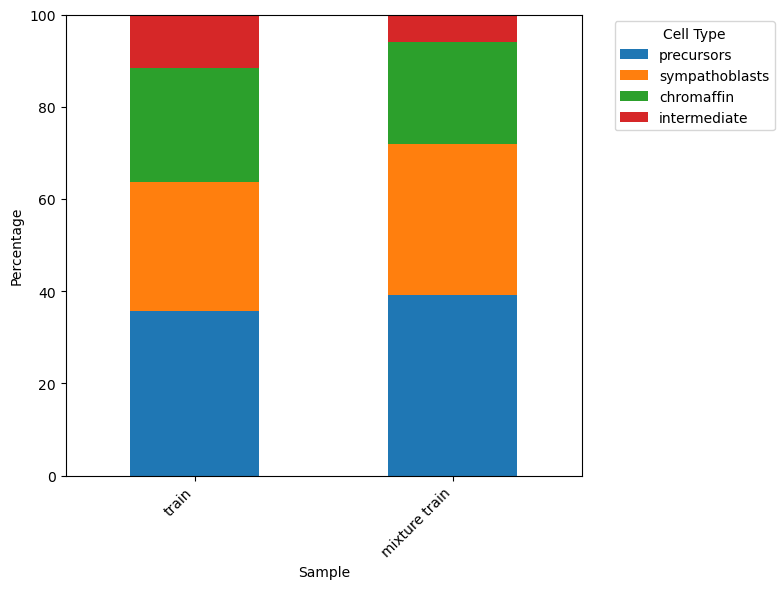

cell_type      precursors  sympathoblasts  chromaffin  intermediate
train           35.722222       28.055556   24.722222     11.500000
mixture train   39.222222       32.722222   22.000000      6.055556


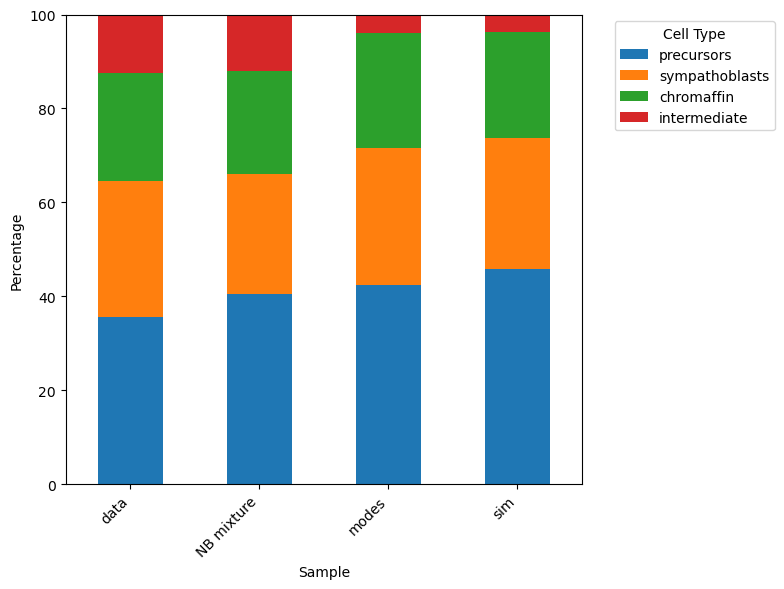

cell_type   precursors  sympathoblasts  chromaffin  intermediate
data         35.583333       28.916667   23.083333     12.416667
NB mixture   40.500000       25.555556   22.000000     11.944444
modes        42.444444       29.055556   24.500000      4.000000
sim          45.833333       27.888889   22.555556      3.722222


In [18]:
p = './../collaborations/Data_Olivier/' 

adata_full = ad.read_h5ad(p+'Data/data_full.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p, split='full')
check_cell_types_full(clf, p)

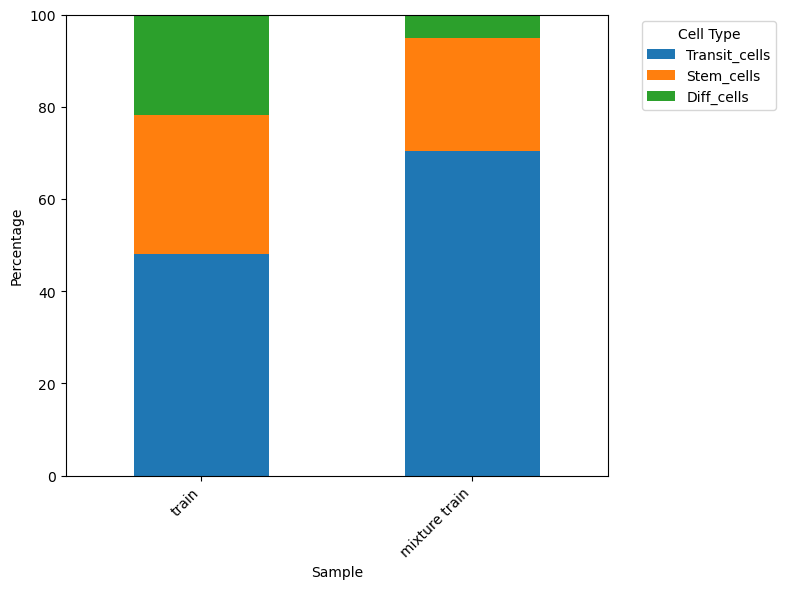

cell_type      Transit_cells  Stem_cells  Diff_cells
train              48.132992   29.974425   21.892583
mixture train      70.471807   24.487917    5.040276


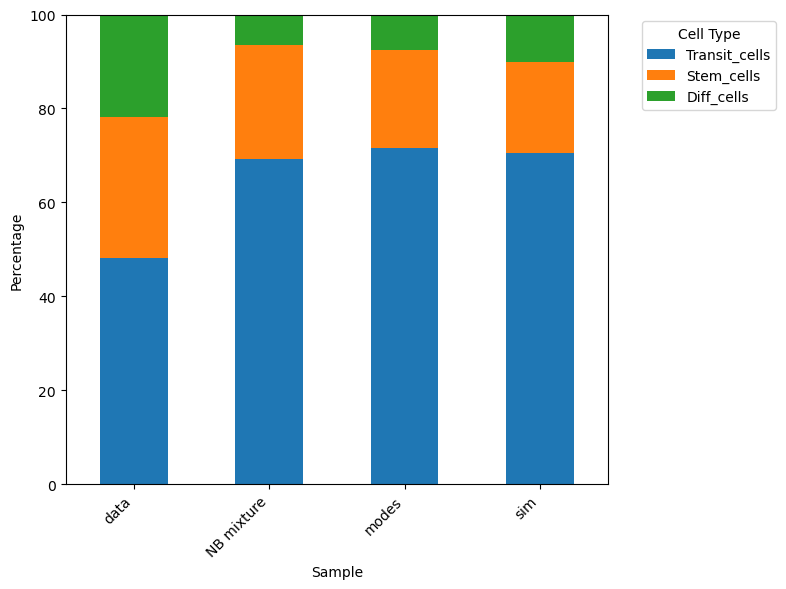

cell_type   Transit_cells  Stem_cells  Diff_cells
data            48.132992   29.974425   21.892583
NB mixture      69.228999   24.188723    6.582278
modes           71.691600   20.690449    7.617952
sim             70.540852   19.263521   10.195627


In [19]:
p = './../collaborations/orga_Olivier/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
clf = train_classifier(adata_full, label_key=label)
# check_cell_types_init(clf, p)
check_cell_types_mixture(clf, p)
check_cell_types_full(clf, p)

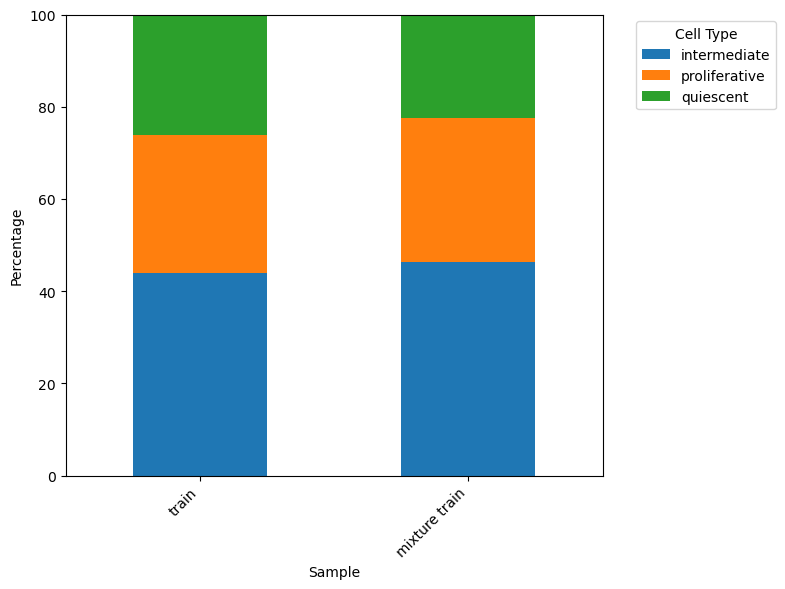

cell_type      intermediate  proliferative  quiescent
train             43.854167      29.927083  26.218750
mixture train     46.385417      31.260417  22.354167


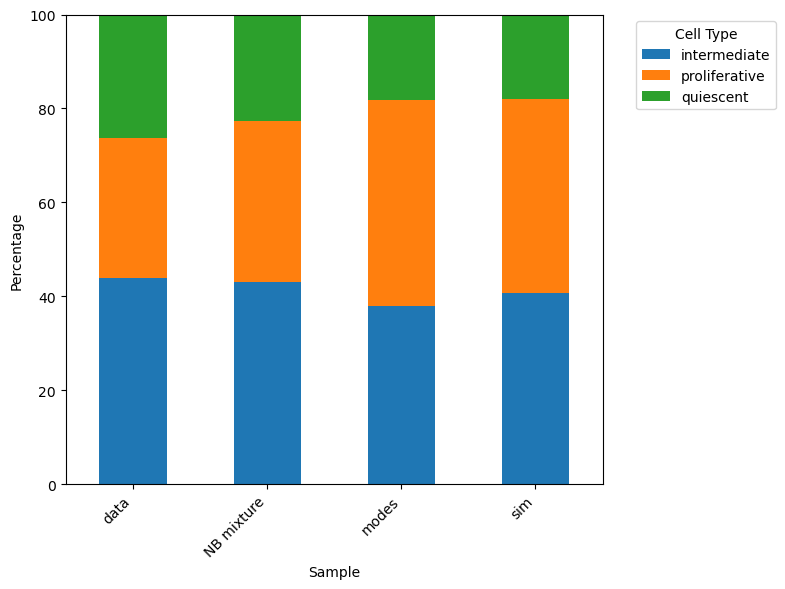

cell_type   intermediate  proliferative  quiescent
data           43.854167      29.927083  26.218750
NB mixture     43.177083      34.166667  22.656250
modes          37.906250      43.989583  18.104167
sim            40.677083      41.343750  17.979167


In [20]:
p = './../collaborations/copycat/RMS_all/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p)
check_cell_types_full(clf, p)

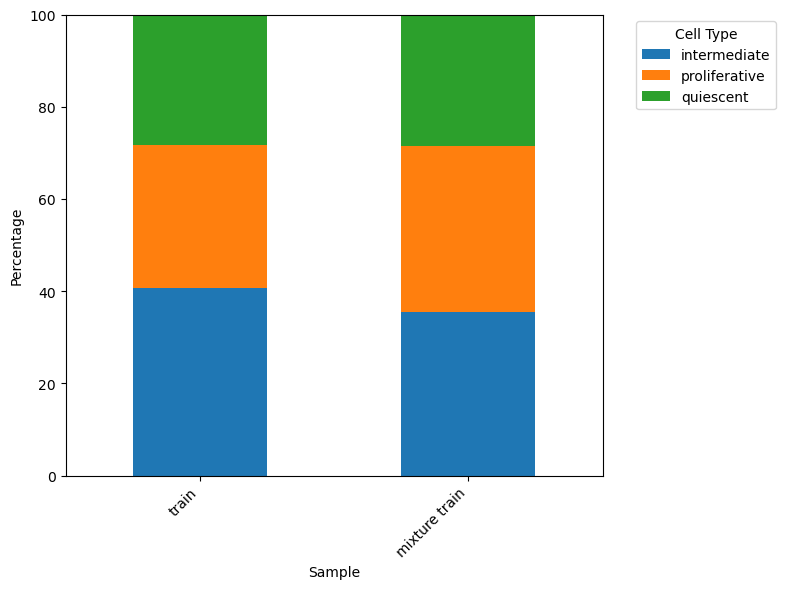

cell_type      intermediate  proliferative  quiescent
train             40.637221      31.078905  28.283874
mixture train     35.392225      36.174373  28.433402


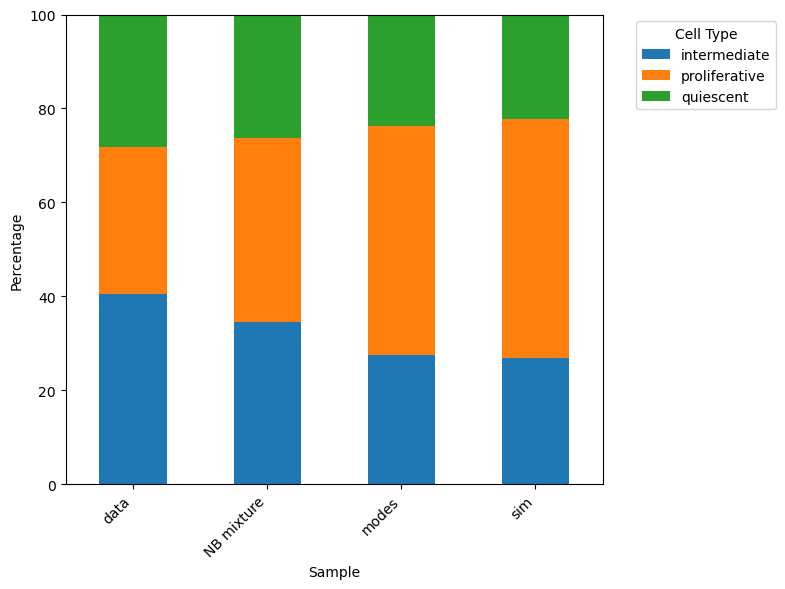

cell_type   intermediate  proliferative  quiescent
data           40.637221      31.078905  28.283874
NB mixture     34.483552      39.337474  26.178974
modes          27.582241      48.677249  23.740511
sim            26.926616      50.805153  22.268231


In [21]:
p = './../collaborations/copycat/RMS2V3/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p)
check_cell_types_full(clf, p)

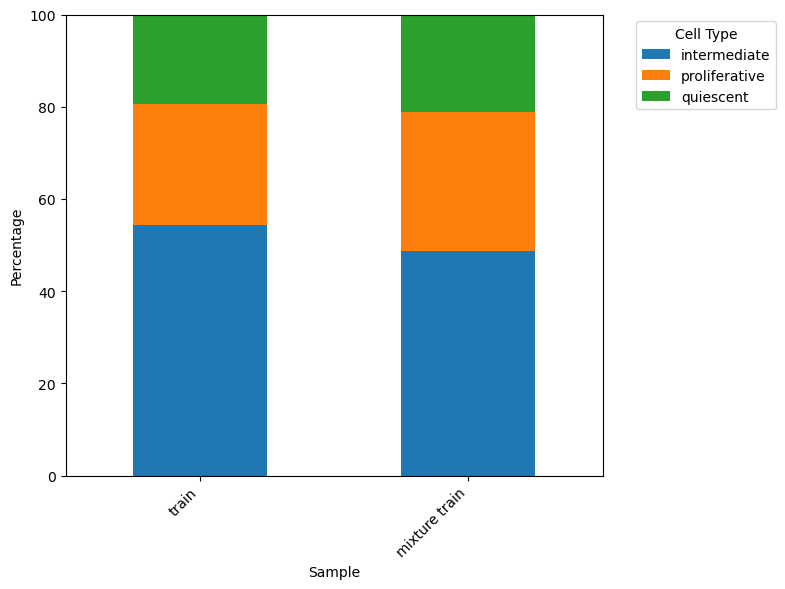

cell_type      intermediate  proliferative  quiescent
train             54.303932      26.381509  19.314559
mixture train     48.671626      30.180659  21.147715


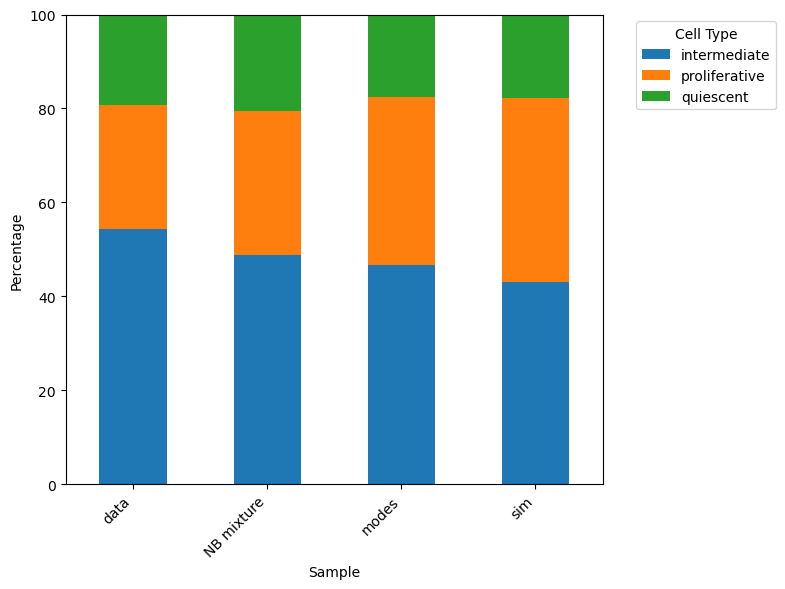

cell_type   intermediate  proliferative  quiescent
data           54.303932      26.381509  19.314559
NB mixture     48.752654      30.812102  20.435244
modes          46.788747      35.668790  17.542463
sim            43.179406      39.065817  17.754777


In [22]:
p = './../collaborations/copycat/RD136/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p)
check_cell_types_full(clf, p)

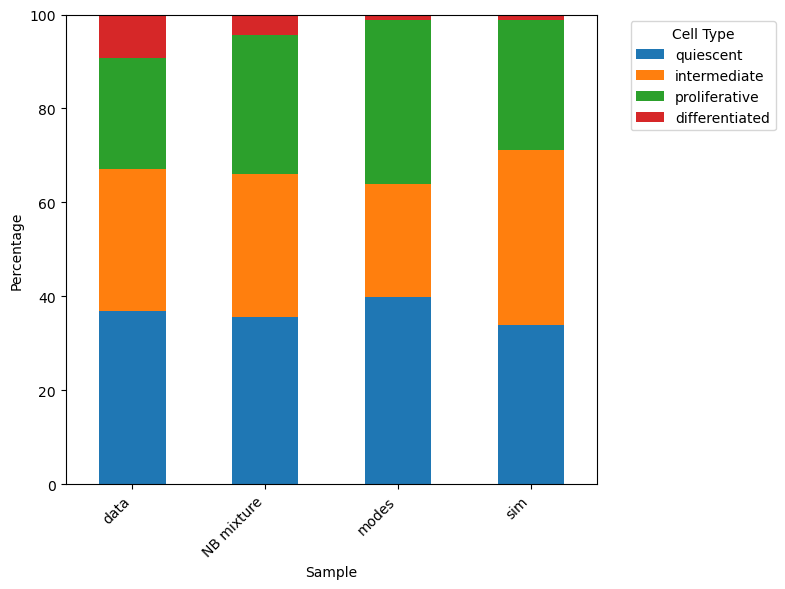

cell_type   quiescent  intermediate  proliferative  differentiated
data        36.827957     30.261137      23.732719        9.178187
NB mixture  35.560676     30.568356      29.608295        4.262673
modes       39.861751     24.039939      34.946237        1.152074
sim         33.986175     37.135177      27.649770        1.228879


In [23]:
p = './../collaborations/copycat/RMS10/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_full(clf, p)

In [3]:
p = './../tests/Semrau/'

adata_full = ad.read_h5ad(p+'Data/data_full.h5ad')
print(adata_full)
clf = train_classifier(adata_full, label_key=label)
check_cell_types_full(clf, p)

AnnData object with n_obs × n_vars = 2449 × 41
    obs: 'time', 'score_Pluripotency', 'score_Post-implantation_Epiblast', 'score_Extraembryonic_Endoderm', 'score_Neuroectoderm', 'zscore_Pluripotency', 'zscore_Post-implantation_Epiblast', 'zscore_Extraembryonic_Endoderm', 'zscore_Neuroectoderm', 'cell_type', 'leiden_sig', 'leiden_cell_type'
    var: 'd0', 'd1'
    obsm: 'X_pca_sig', 'X_umap_sig'


KeyError: 'cell_type'

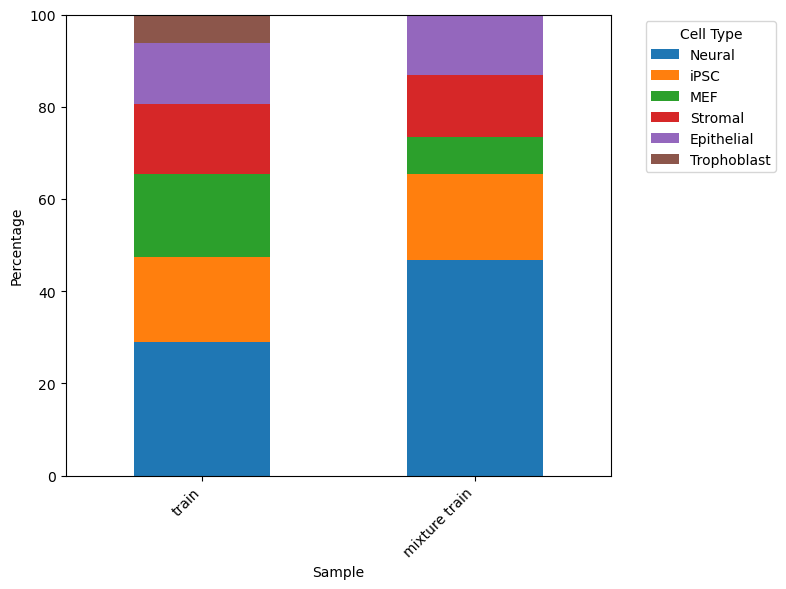

cell_type         Neural       iPSC        MEF    Stromal  Epithelial  \
train          28.906250  18.483383  17.999752  15.104167   13.262649   
mixture train  46.732391  18.756200   8.023313  13.318452   12.760417   

cell_type      Trophoblast  
train             6.243800  
mixture train     0.409226  


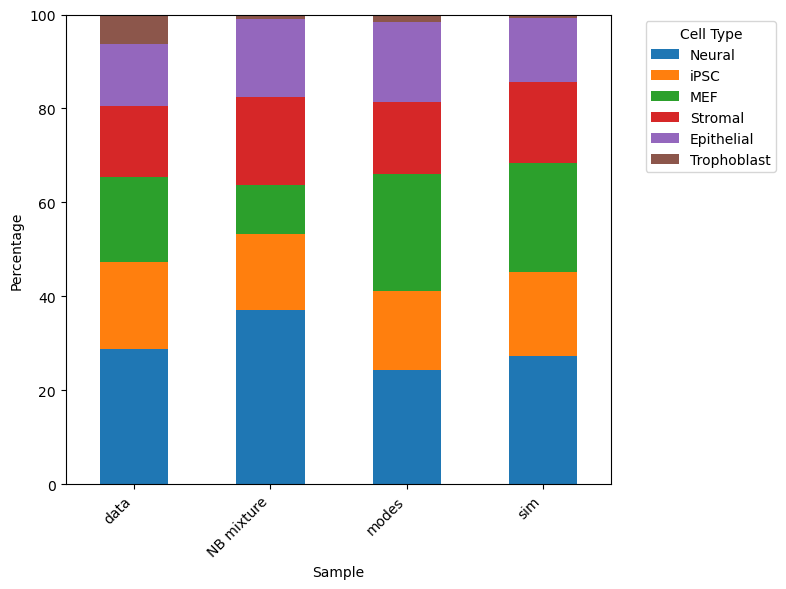

cell_type      Neural       iPSC        MEF    Stromal  Epithelial  \
data        28.906250  18.483383  17.999752  15.104167   13.262649   
NB mixture  37.081256  16.168110  10.469693  18.687134   16.741013   
modes       24.319951  16.832852  24.805388  15.319689   17.082131   
sim         27.263186  17.943672  23.265984  17.173970   13.570366   

cell_type   Trophoblast  
data           6.243800  
NB mixture     0.852795  
modes          1.639990  
sim            0.782822  


In [ ]:
p = './../collaborations/Schiebinger/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
sc.pp.log1p(adata_full)
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p)
check_cell_types_full(clf, p)